# 02 Growth Monitoring

## Business Question

2015年7月至10月的新增用户规模是否发生明显且持续的异常变化？

## Analysis Objective

计算每日新增、7日移动平均和每日Source Mix，定位变化日期并验证异常是否持续。本Notebook只回答“发生了什么”，不分析用户质量或原因。

## Data Used

- `data/processed/user_growth_profile.csv`
- 仅使用`msno`、`registration_date`、`registered_via`。

## Key Metrics

- Daily New Users。
- 7-day Moving Average。
- 各Source每日新增人数及占比。
- 异常前、断点日和异常后日均新增。


In [1]:
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
AS_OF_DATE = pd.Timestamp("2015-10-16")
ANALYSIS_START = pd.Timestamp("2015-07-01")
pd.set_option("display.max_columns", 50)


In [2]:
users = pd.read_csv(
    PROCESSED_DIR / "user_growth_profile.csv",
    usecols=["msno", "registration_date", "registered_via"],
    dtype={"msno": "string", "registered_via": "Int16"},
    parse_dates=["registration_date"],
)
assert users.msno.is_unique
calendar = pd.date_range(ANALYSIS_START, AS_OF_DATE)
daily = (users.groupby("registration_date").msno.nunique()
         .reindex(calendar, fill_value=0).rename("new_users")
         .rename_axis("registration_date").reset_index())
daily["moving_avg_7d"] = daily.new_users.rolling(7, min_periods=1).mean()
daily.head()


,registration_date,new_users,moving_avg_7d
0,2015-07-01,3530,3530.000000
1,2015-07-02,3398,3464.000000
2,2015-07-03,3478,3468.666667
3,2015-07-04,3851,3564.250000
4,2015-07-05,3320,3515.400000


In [3]:
source_mix = (users.groupby(["registration_date", "registered_via"]).msno.nunique()
              .rename("source_new_users").reset_index())
source_mix = source_mix.merge(
    daily[["registration_date", "new_users"]].rename(columns={"new_users": "daily_new_users"}),
    on="registration_date", how="left")
source_mix["source_share"] = source_mix.source_new_users / source_mix.daily_new_users
source_mix.head()


,registration_date,registered_via,source_new_users,daily_new_users,source_share
0,2015-07-01,2,1,3530,0.000283
1,2015-07-01,3,1780,3530,0.504249
2,2015-07-01,7,297,3530,0.084136
3,2015-07-01,8,1,3530,0.000283
4,2015-07-01,9,1450,3530,0.410765


In [4]:
periods = [
    ("Historical baseline", "2015-07-01", "2015-09-30"),
    ("Pre-break", "2015-10-01", "2015-10-06"),
    ("Break date", "2015-10-07", "2015-10-07"),
    ("Post-break", "2015-10-08", "2015-10-16"),
]
period_summary = []
for label, start, end in periods:
    frame = daily[daily.registration_date.between(start, end)]
    period_summary.append({
        "period": label, "days": len(frame), "new_users": int(frame.new_users.sum()),
        "avg_daily_new_users": frame.new_users.mean(),
        "std_daily_new_users": frame.new_users.std(ddof=0),
        "min_daily_new_users": int(frame.new_users.min()),
        "max_daily_new_users": int(frame.new_users.max()),
    })
period_summary = pd.DataFrame(period_summary)
display(period_summary)


,period,days,new_users,avg_daily_new_users,std_daily_new_users,min_daily_new_users,max_daily_new_users
0,Historical baseline,92,392366,4264.847826,1114.962321,2974,7646
1,Pre-break,6,22771,3795.166667,649.527884,3177,4728
2,Break date,1,6847,6847.000000,0.000000,6847,6847
3,Post-break,9,82700,9188.888889,1752.111770,7074,12413


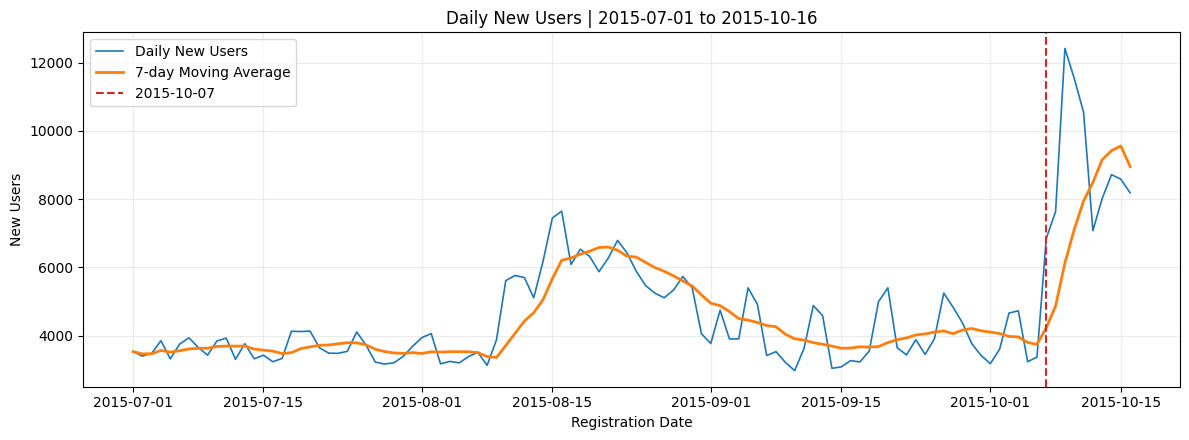

In [5]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(daily.registration_date, daily.new_users, label="Daily New Users", linewidth=1.2)
ax.plot(daily.registration_date, daily.moving_avg_7d, label="7-day Moving Average", linewidth=2)
ax.axvline(pd.Timestamp("2015-10-07"), color="tab:red", linestyle="--", label="2015-10-07")
ax.set(title="Daily New Users | 2015-07-01 to 2015-10-16", xlabel="Registration Date", ylabel="New Users")
ax.grid(alpha=.25); ax.legend(); fig.tight_layout(); plt.show()


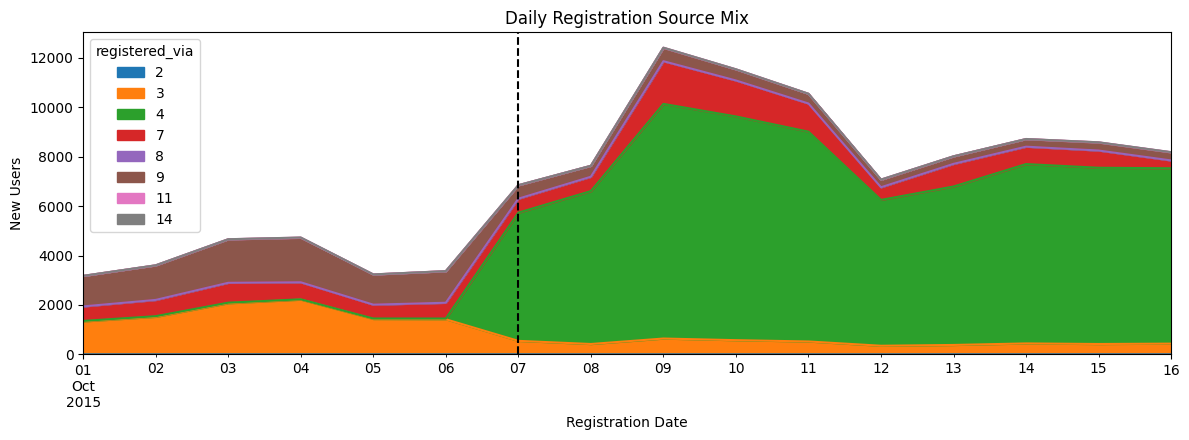

In [6]:
oct_source = source_mix[source_mix.registration_date.ge("2015-10-01")]
pivot = oct_source.pivot(index="registration_date", columns="registered_via", values="source_new_users").fillna(0)
fig, ax = plt.subplots(figsize=(12, 4.5))
pivot.plot.area(ax=ax, stacked=True)
ax.axvline(pd.Timestamp("2015-10-07"), color="black", linestyle="--")
ax.set(title="Daily Registration Source Mix", xlabel="Registration Date", ylabel="New Users")
fig.tight_layout(); plt.show()


## Monitoring Conclusion

截至2015-10-16，观察到2015-10-07之后持续性的新增规模和来源结构变化；2015-10-08至2015-10-16仍维持高位，因此不是单日峰值。该结果属于监控层面的数据观察，仍需结合业务活动记录确认是否存在渠道、营销活动或数据口径因素影响。本章不解释变化原因，也不评价Source 4用户质量。
